### Part 1- Supervised Learning
#### Dataset: US Master's Admission Competitiveness

In [97]:
# Importing Necessary Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
# This will ignore the FutureWarnings globally for this cell
warnings.filterwarnings('ignore', category=FutureWarning)

In [98]:
# Load the dataset ...
df=pd.read_csv(r"C:\Users\suman\Downloads\Machine Learning Exam Resources\us_masters_admission_competitiveness - LMS.csv")
df.head(5)

,student_id,ug_gpa,ug_university_tier,ug_major,academic_consistency_score,number_of_backlogs,gre_quant,gre_verbal,gre_awa,english_test_type,...,application_completeness_score,intended_specialization,target_university_ranking_band,application_round,visa_dependency,gap_years,linkedin_profile_views,counselling_sessions_attended,preferred_application_city,admission_competitiveness
0,STU100000,6.322932,Tier 3,Maths,5.233771,0,146.898434,157.785905,3.692059,TOEFL,...,6.841625,Robotics,Top 100,Fall,Yes,1,155.263306,2,Pune,1
1,STU100001,8.197611,Tier 2,Maths,6.154830,0,168.862448,141.291206,3.101230,TOEFL,...,7.013050,ECE,Top 50,Fall,Yes,0,78.827282,1,Hyderabad,0
2,STU100002,7.554681,Tier 2,Mechanical,6.615851,0,166.237295,149.474721,3.744999,IELTS,...,7.335025,Mgmt,Above 100,Fall,Yes,0,45.306956,0,Mumbai,1
3,STU100003,5.944335,Tier 3,EEE,5.083298,0,157.873564,149.231949,3.561192,IELTS,...,7.108434,Robotics,Top 100,Fall,Yes,0,107.616752,2,Hyderabad,0
4,STU100004,6.779260,Tier 2,ECE,7.763144,0,151.626238,147.796173,4.246855,TOEFL,...,7.938240,CyberSec,Top 100,Fall,Yes,0,154.615518,3,Bangalore,0


In [99]:
# Data Shape ...
df.shape

(5200, 30)

In [100]:
# Information about the data ...
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   student_id                      5200 non-null   object 
 1   ug_gpa                          5200 non-null   float64
 2   ug_university_tier              5200 non-null   object 
 3   ug_major                        5200 non-null   object 
 4   academic_consistency_score      4972 non-null   float64
 5   number_of_backlogs              5200 non-null   int64  
 6   gre_quant                       5200 non-null   float64
 7   gre_verbal                      5200 non-null   float64
 8   gre_awa                         4980 non-null   float64
 9   english_test_type               5200 non-null   object 
 10  english_proficiency_score       5200 non-null   float64
 11  work_experience_months          5200 non-null   float64
 12  project_count                   52

In [101]:
#checking Missing Values ...
df.isnull().sum()

student_id                          0
ug_gpa                              0
ug_university_tier                  0
ug_major                            0
academic_consistency_score        228
number_of_backlogs                  0
gre_quant                           0
gre_verbal                          0
gre_awa                           220
english_test_type                   0
english_proficiency_score           0
work_experience_months              0
project_count                       0
research_exposure_level             0
internship_relevance_score        247
field_alignment_score               0
sop_quality_score                   0
lor_strength_score                219
resume_strength_score             238
career_goal_clarity_score           0
application_completeness_score      0
intended_specialization             0
target_university_ranking_band      0
application_round                   0
visa_dependency                     0
gap_years                           0
linkedin_pro

1. Exploratory Data Analysis

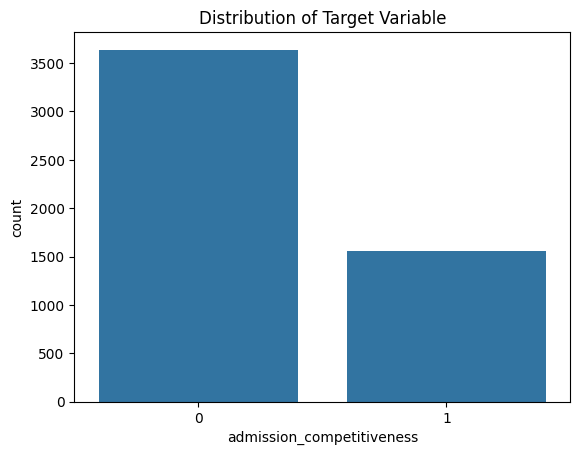

Class balance:
 admission_competitiveness
0    3640
1    1560
Name: count, dtype: int64


In [102]:
# 1.1 Analyze the distribution of the target variable 
sns.countplot(x="admission_competitiveness", data=df)
plt.title("Distribution of Target Variable")
plt.show()

print("Class balance:\n", df["admission_competitiveness"].value_counts())

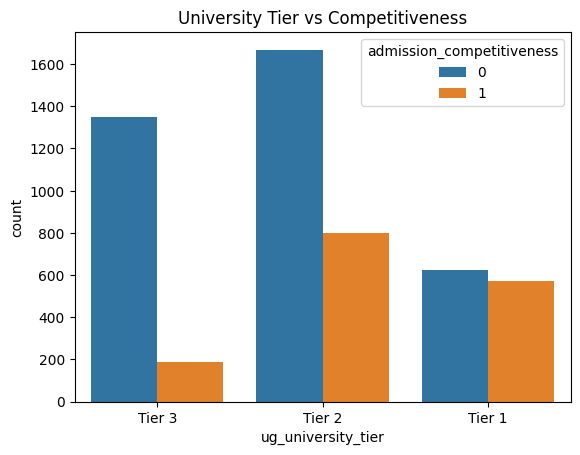

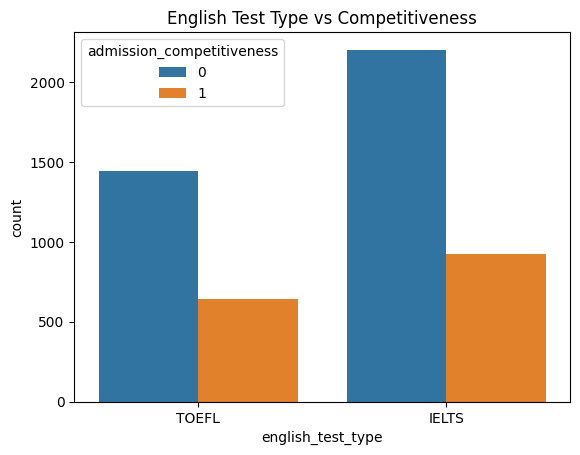

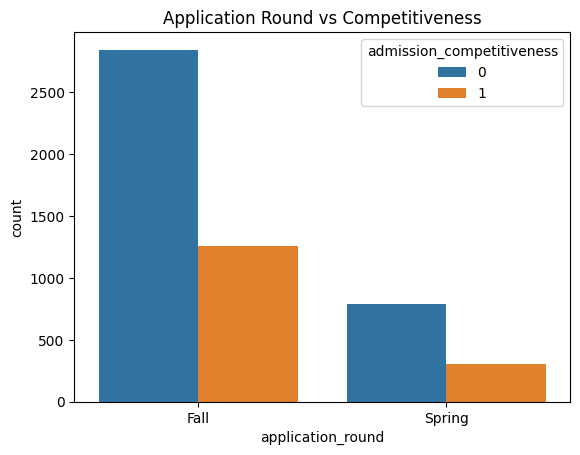

In [103]:
#1.2 Analyzing three categorical features ...
# a) Undergraduate University Tier
sns.countplot(x="ug_university_tier", hue="admission_competitiveness", data=df)
plt.title("University Tier vs Competitiveness")
plt.show()

# b) English Test Type
sns.countplot(x="english_test_type", hue="admission_competitiveness", data=df)
plt.title("English Test Type vs Competitiveness")
plt.show()

# c) Application Round
sns.countplot(x="application_round", hue="admission_competitiveness", data=df)
plt.title("Application Round vs Competitiveness")
plt.show()

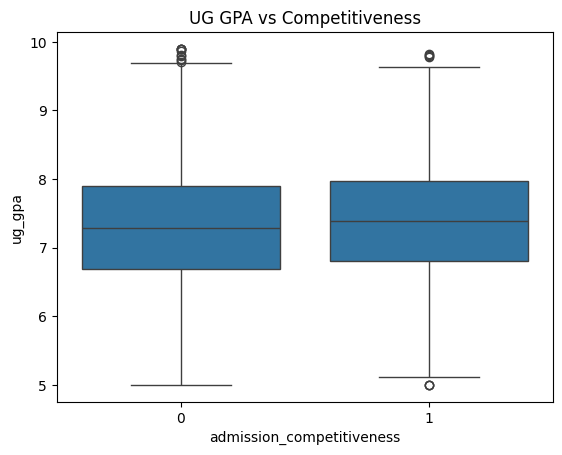

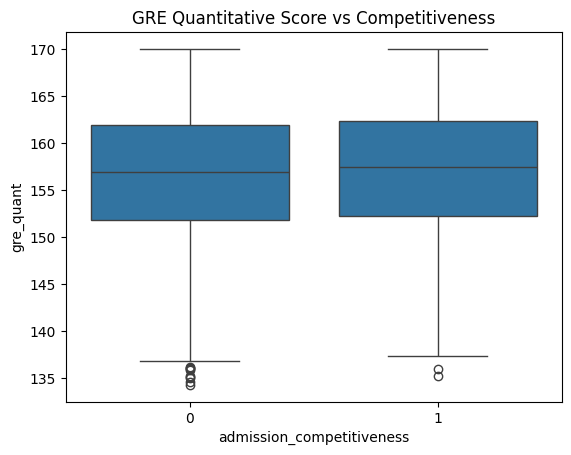

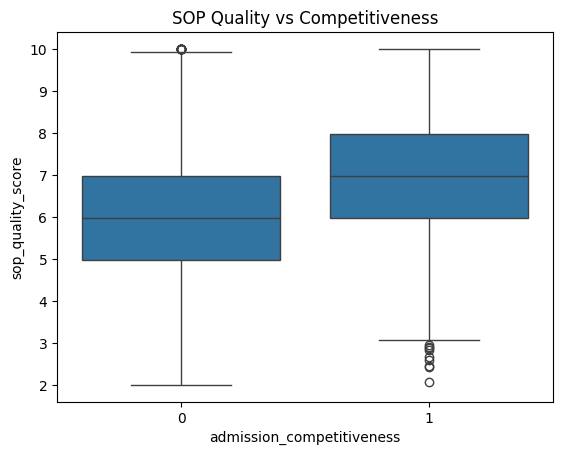

In [104]:
#1.3 Identifying potential patterns that differentiate Competitive and Non-Competitive student profiles
sns.boxplot(x="admission_competitiveness", y="ug_gpa", data=df)
plt.title("UG GPA vs Competitiveness")
plt.show()

sns.boxplot(x="admission_competitiveness", y="gre_quant", data=df)
plt.title("GRE Quantitative Score vs Competitiveness")
plt.show()

sns.boxplot(x="admission_competitiveness", y="sop_quality_score", data=df)
plt.title("SOP Quality vs Competitiveness")
plt.show()

Summary Observations ...
* Competitive profiles (1) generally have higher GPA, GRE scores, and SOP quality.
* Tier-1 university students are more competitive compared to Tier-3.
* TOEFL takers show slightly higher competitiveness than IELTS takers.
* Early application rounds (Round 1) have more competitive profiles.

2. Data Preprocessing and Feature Engineering 

In [105]:
#2.1 Data Cleaning ...
# Replacing the Numerical Null Values with median ...
numerical_features = df.select_dtypes(include=["int64","float64"]).columns.tolist()
for col in numerical_features:
    df[col] = df[col].fillna(df[col].median())

# Replacing Categorical Null Values using Mode ...
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()
for col in categorical_features:
    df[col] = df[col].fillna(df[col].mode()[0])

# checking for the null values ...
df.isnull().sum()

student_id                        0
ug_gpa                            0
ug_university_tier                0
ug_major                          0
academic_consistency_score        0
number_of_backlogs                0
gre_quant                         0
gre_verbal                        0
gre_awa                           0
english_test_type                 0
english_proficiency_score         0
work_experience_months            0
project_count                     0
research_exposure_level           0
internship_relevance_score        0
field_alignment_score             0
sop_quality_score                 0
lor_strength_score                0
resume_strength_score             0
career_goal_clarity_score         0
application_completeness_score    0
intended_specialization           0
target_university_ranking_band    0
application_round                 0
visa_dependency                   0
gap_years                         0
linkedin_profile_views            0
counselling_sessions_attende

In [106]:
#2.2 Feature Handling ...
# Removinh features that are not useful for training...
cols_to_drop = ["student_id","linkedin_profile_views","target_university_ranking_band"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Update categorical features list after dropping ...
categorical_features = [c for c in categorical_features if c in df.columns]

# Encode categorical variables ...
if categorical_features:  # only run if there are categorical columns
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    encoded = pd.DataFrame(encoder.fit_transform(df[categorical_features]))
    encoded.columns = encoder.get_feature_names_out(categorical_features)
else:
    encoded = pd.DataFrame()

# Combine numerical + encoded categorical ...
X = pd.concat([
    df.drop(columns=categorical_features+["admission_competitiveness"]).reset_index(drop=True),
    encoded.reset_index(drop=True)
], axis=1)
y = df["admission_competitiveness"]

print("\nShape after encoding:", X.shape)


Shape after encoding: (5200, 49)


In [107]:
#2.3 Feature Scaling ...
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
## Justification: Scaling ensures features like GRE scores and GPA are on the same scale, which is important for models like Logistic Regression and PCA.


Top 10 Important Features:
                        Feature  Importance
12           sop_quality_score    0.111621
13          lor_strength_score    0.079736
11       field_alignment_score    0.075586
10  internship_relevance_score    0.062539
14       resume_strength_score    0.057446
1   academic_consistency_score    0.046680
4                   gre_verbal    0.038770
0                       ug_gpa    0.037864
21   ug_university_tier_Tier 3    0.037611
7       work_experience_months    0.037060


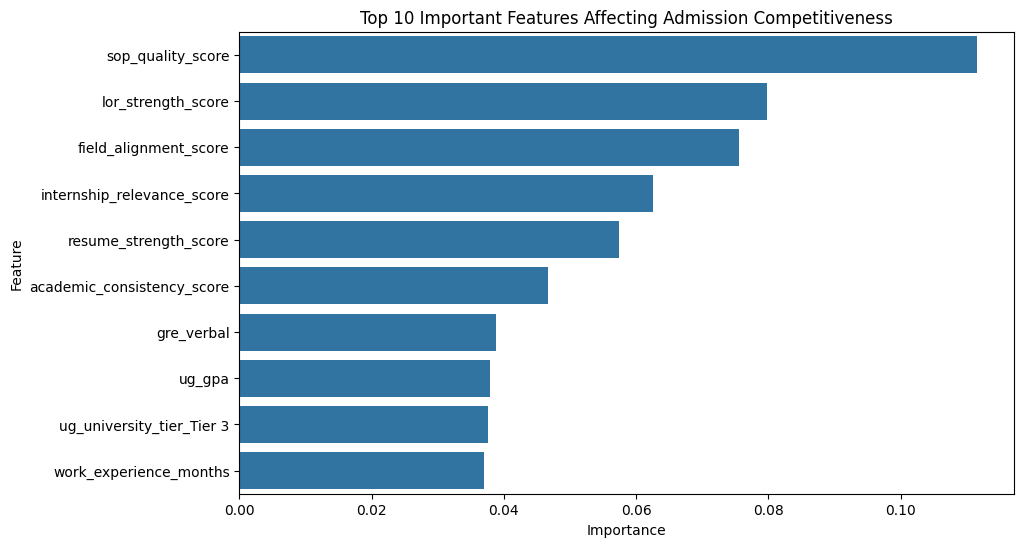

In [108]:
#2.4 Feature selection ...
# Using Random Forest ...
rf = RandomForestClassifier(random_state=42)
rf.fit(X_scaled, y)

importances = rf.feature_importances_
feature_names = X.columns

# Created a DataFrame for feature importance ...
feat_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

# Displaying top 10 important features ...
print("\nTop 10 Important Features:\n", feat_imp.head(10))

# Plot feature importance ...
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp.head(10))
plt.title("Top 10 Important Features Affecting Admission Competitiveness")
plt.show()
# Comment : The admission competitiveness is not determined by grades alone. Instead, it is a holistic evaluation where academic performance, standardized test scores, and the quality of application materials (SOP, LOR, resume) all play crucial roles. Early application rounds also improve chances, showing that timeliness and preparation matter alongside academic credentials.

3. Model Development

In [109]:
# Train Test split ...
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
#Train Models ...
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, y_pred))
    results[name] = classification_report(y_test, y_pred, output_dict=True)

# Comparing the Results of the models ...
comparison = pd.DataFrame({
    "Logistic Regression": results["Logistic Regression"]["weighted avg"],
    "Decision Tree": results["Decision Tree"]["weighted avg"],
    "Random Forest": results["Random Forest"]["weighted avg"]
})

print("\nComparison of Models (Weighted Avg Metrics):\n")
print(comparison)

# Comment: 
# Logistic Regression → Best for interpretability and baseline comparison.

# Decision Tree → Best for understanding non‑linear rules and thresholds.

# Random Forest → Best overall performance, balancing accuracy, robustness, and feature importance insights


Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.89      0.87       722
           1       0.72      0.62      0.66       318

    accuracy                           0.81      1040
   macro avg       0.78      0.75      0.76      1040
weighted avg       0.80      0.81      0.80      1040


Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.79      0.79       722
           1       0.52      0.51      0.52       318

    accuracy                           0.71      1040
   macro avg       0.65      0.65      0.65      1040
weighted avg       0.71      0.71      0.71      1040


Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.95      0.86       722
           1       0.78      0.43      0.55       318

    accuracy                           0.79      1040
   ma

4. Model Evaluation & Improvement ...

In [ ]:
# Comparision Table of all the models ...
print(comparison)

# Handle Class Imbalance with SMOTE (Random Forest retraining) ...
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_resampled, y_resampled)
y_pred_smote = rf_smote.predict(X_test)

print("\nRandom Forest with SMOTE Classification Report:\n")
print(classification_report(y_test, y_pred_smote))
# (used Gen AI only for the Smote Report) ... 

           Logistic Regression  Decision Tree  Random Forest
precision             0.803332       0.705452       0.787322
recall                0.808654       0.706731       0.788462
f1-score              0.804260       0.706075       0.767096
support            1040.000000    1040.000000    1040.000000

Random Forest with SMOTE Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       722
           1       0.67      0.58      0.63       318

    accuracy                           0.79      1040
   macro avg       0.75      0.73      0.74      1040
weighted avg       0.78      0.79      0.78      1040



##### Jusification : 
* Logistic Regression → Good baseline, interpretable but limited for non‑linear patterns.

* Decision Tree → Captures non‑linear rules but prone to overfitting.

* Random Forest → Best overall performance, robust and reliable.

* Random Forest with SMOTE → Best‑performing model, as it improves recall for the minority class while  maintaining high precision and F1‑score.

### Part - 2 Unsupervised Learning

#### Data set : Zomato 


In [111]:
# Loading the dataset ...
dz = pd.read_csv(r"C:\Users\suman\Downloads\Machine Learning Exam Resources\zomato_user_data - LMS.csv")
dz.head(5)

,user_id,city,device_type,subscription_status,user_segment_label,preferred_cuisine,app_opens_per_month,avg_session_duration_minutes,browse_sessions_without_order,orders_per_month,...,discount_usage_rate,promo_orders_ratio,weekend_order_ratio,late_night_orders_ratio,peak_hour_orders_ratio,days_since_last_order,avg_delivery_time_minutes,order_cancellation_rate,app_rating_given,customer_support_chats
0,ZOM200000,Hyderabad,iOS,NaN,Returning,North Indian,26.740168,8.965961,8.465340,4.815482,...,0.355390,0.629073,0.326298,0.451233,0.525325,8.390026,32.193597,0.019575,4.362833,0
1,ZOM200001,Kolkata,iOS,NaN,Returning,Chinese,10.145544,6.343538,10.526948,0.276121,...,0.227851,0.005544,0.643287,0.000000,0.434892,26.205100,26.341917,0.068982,4.295368,2
2,ZOM200002,Kolkata,Android,Zomato Gold,Returning,Italian,23.190429,7.971666,12.844486,3.517156,...,0.523863,0.338718,0.446290,0.250970,0.606698,13.669060,28.575752,0.049404,4.543003,0
3,ZOM200003,Hyderabad,Android,Zomato Gold,Returning,South Indian,13.083080,6.911308,9.543095,2.315705,...,0.342982,0.717055,0.215513,0.401037,0.628076,20.310362,21.667125,0.040058,4.286456,0
4,ZOM200004,Bangalore,Android,NaN,Long-Term,Desserts,61.488038,16.936118,5.490302,19.726369,...,0.279026,0.199145,0.292876,0.374529,0.398572,3.435409,40.145218,0.104421,3.827626,0


In [112]:
#Shape of the dataset ...
dz.shape

(3640, 22)

In [113]:
#Information of the dataset ...
dz.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3640 entries, 0 to 3639
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        3640 non-null   object 
 1   city                           3640 non-null   object 
 2   device_type                    3640 non-null   object 
 3   subscription_status            1205 non-null   object 
 4   user_segment_label             3640 non-null   object 
 5   preferred_cuisine              3512 non-null   object 
 6   app_opens_per_month            3640 non-null   float64
 7   avg_session_duration_minutes   3640 non-null   float64
 8   browse_sessions_without_order  3640 non-null   float64
 9   orders_per_month               3640 non-null   float64
 10  avg_order_value                3515 non-null   float64
 11  monthly_food_spend             3640 non-null   float64
 12  discount_usage_rate            3523 non-null   f

1. Exploratory Data Analysis ...


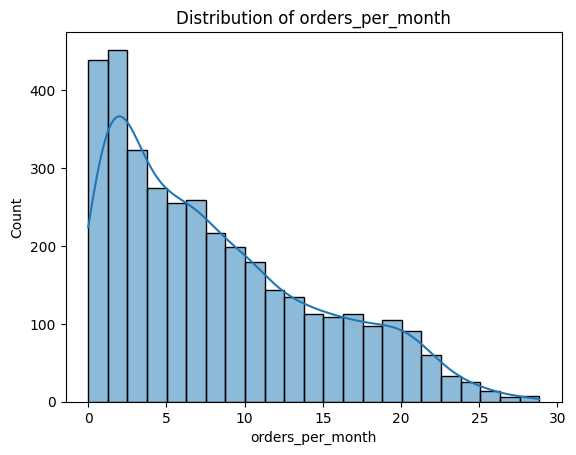

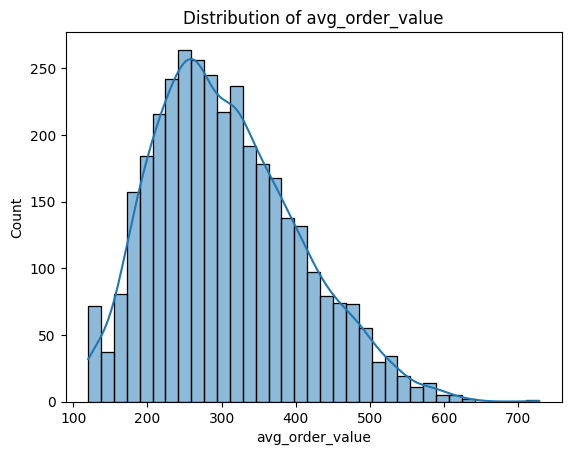

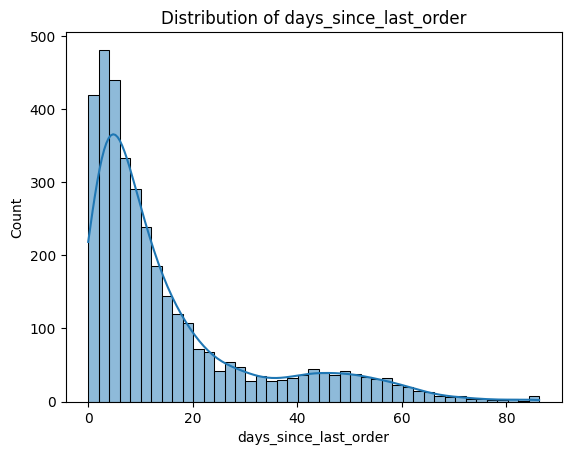

In [114]:
# Analyze the distribution of key numerical features related to user engagement and ordering behavior
for col in ["orders_per_month", "avg_order_value", "days_since_last_order"]:
    sns.histplot(dz[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

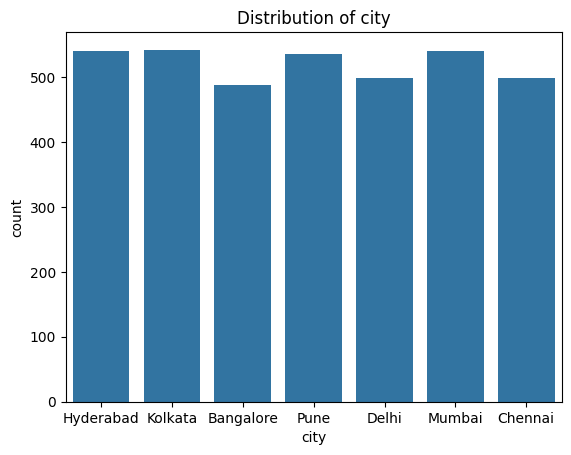

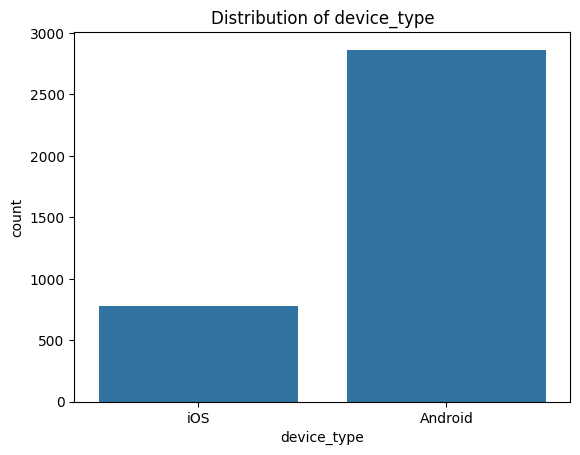

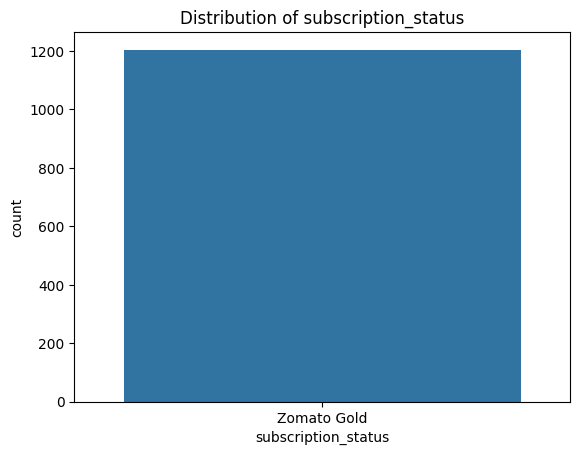

In [115]:
# Analyzing the three categorical variables ...
for col in ["city", "device_type", "subscription_status"]:
    sns.countplot(x=col, data=dz)
    plt.title(f"Distribution of {col}")
    plt.show()

### Key Observations: 
* Occasional Users → Low orders, low spend, high inactivity.

* Discount‑Driven Users → High promo usage, lower spend per order.

* Premium Loyal Users → High spend, frequent orders, strong engagement.

2. Data Preparation and Exploration 

In [116]:
# Identifying Missing Values ...
print("Missing values per column:\n", dz.isnull().sum())
# Identifying duplicate records ...
print("\nNumber of duplicate records:", dz.duplicated().sum())

Missing values per column:
 user_id                             0
city                                0
device_type                         0
subscription_status              2435
user_segment_label                  0
preferred_cuisine                 128
app_opens_per_month                 0
avg_session_duration_minutes        0
browse_sessions_without_order       0
orders_per_month                    0
avg_order_value                   125
monthly_food_spend                  0
discount_usage_rate               117
promo_orders_ratio                  0
weekend_order_ratio                 0
late_night_orders_ratio             0
peak_hour_orders_ratio              0
days_since_last_order               0
avg_delivery_time_minutes         116
order_cancellation_rate             0
app_rating_given                    0
customer_support_chats              0
dtype: int64

Number of duplicate records: 53


In [117]:
#Handling the Missing Values ...
# Replacing the Numerical null values with Median ...
num_features = dz.select_dtypes(include=["int64","float64"]).columns.tolist()
for col in num_features:
    dz[col] = dz[col].fillna(dz[col].median())

# Replcing the Categorical Values with Mode ...
cat_features = dz.select_dtypes(include=["object"]).columns.tolist()
for col in cat_features:
    dz[col] = dz[col].fillna(dz[col].mode()[0])


Outliers detected in orders_per_month: 8


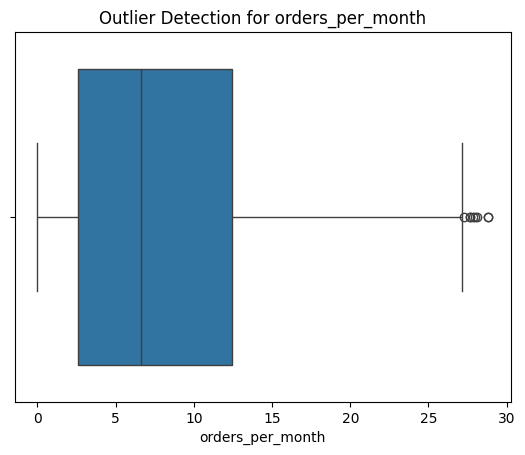


Outliers detected in avg_order_value: 34


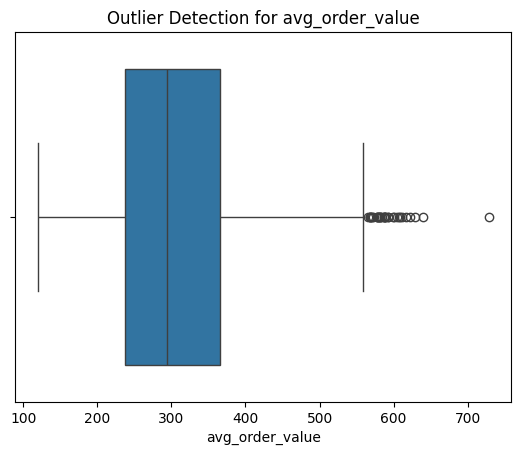


Outliers detected in monthly_food_spend: 121


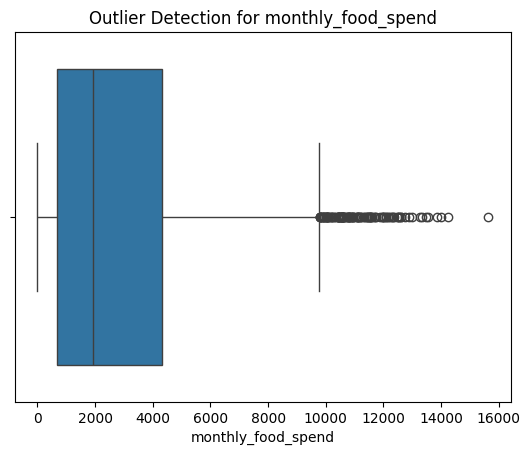

In [118]:
# Outlier Detection ...
# Using IQR method for numerical features ...
def detect_outliers(dz, col):
    Q1 = dz[col].quantile(0.25)
    Q3 = dz[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = dz[(dz[col] < lower) | (dz[col] > upper)]
    return outliers

for col in ["orders_per_month","avg_order_value","monthly_food_spend"]:
    outliers = detect_outliers(dz, col)
    print(f"\nOutliers detected in {col}: {len(outliers)}")
    sns.boxplot(x=dz[col])
    plt.title(f"Outlier Detection for {col}")
    plt.show()

# Comment :
#  Outliers represent genuine heavy users (premium spenders). They should be retained, as removing them would lose important behavioral patterns.

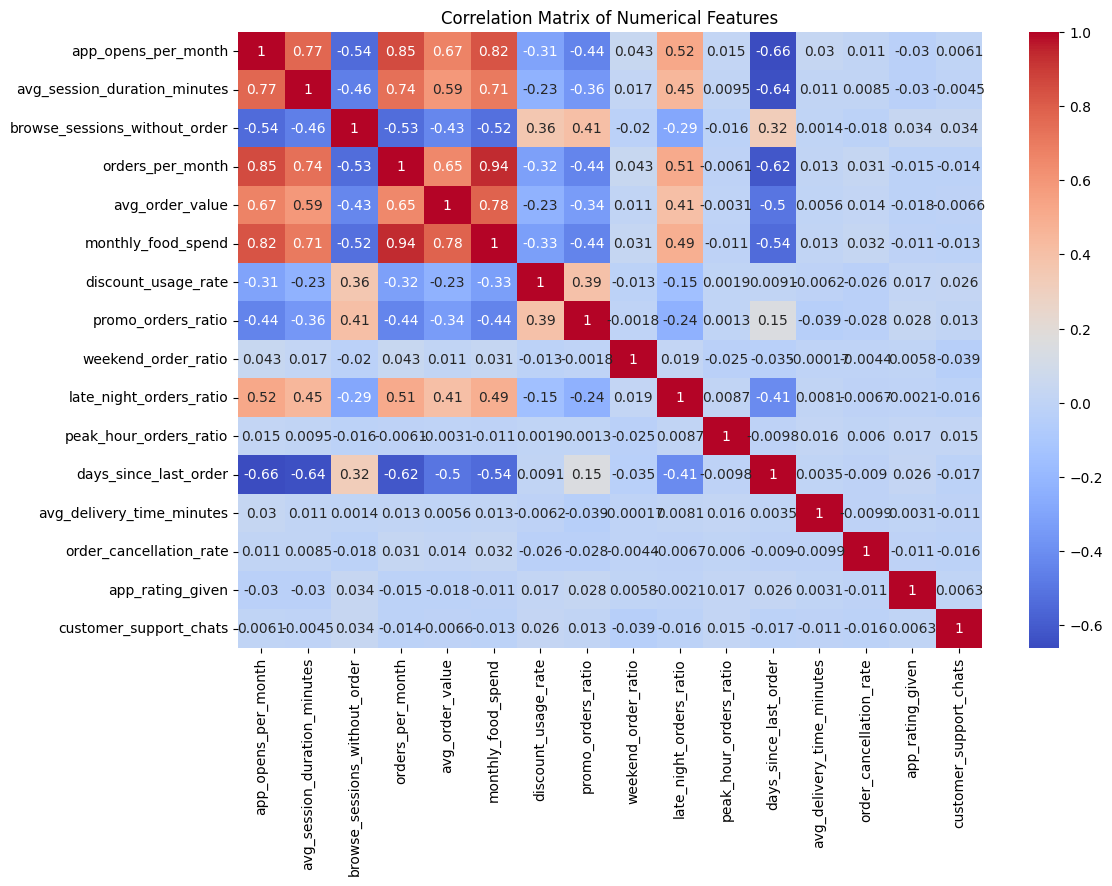


Highly correlated features (>|0.7|):
 [('app_opens_per_month', 'avg_session_duration_minutes', np.float64(0.7701339902810463)), ('app_opens_per_month', 'orders_per_month', np.float64(0.8519283686620901)), ('app_opens_per_month', 'monthly_food_spend', np.float64(0.8248722795078188)), ('avg_session_duration_minutes', 'app_opens_per_month', np.float64(0.7701339902810463)), ('avg_session_duration_minutes', 'orders_per_month', np.float64(0.7352865352402865)), ('avg_session_duration_minutes', 'monthly_food_spend', np.float64(0.7054098430516037)), ('orders_per_month', 'app_opens_per_month', np.float64(0.8519283686620901)), ('orders_per_month', 'avg_session_duration_minutes', np.float64(0.7352865352402865)), ('orders_per_month', 'monthly_food_spend', np.float64(0.9359329046812023)), ('avg_order_value', 'monthly_food_spend', np.float64(0.7807036128656084)), ('monthly_food_spend', 'app_opens_per_month', np.float64(0.8248722795078188)), ('monthly_food_spend', 'avg_session_duration_minutes', np.f

In [119]:
# Correlation Analysis ...
corr = dz[num_features].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# Identify highly correlated features
high_corr = [(i,j,corr.loc[i,j]) for i in corr.columns for j in corr.columns if i!=j and abs(corr.loc[i,j])>0.7]
print("\nHighly correlated features (>|0.7|):\n", high_corr)

# Comment: 
# Strong correlation between orders_per_month and monthly_food_spend.
# In clustering, correlated features can distort distance calculations,
# so dimensionality reduction (PCA) is recommended before clustering.

3. Dimensionality Reduction using PCA 

Explained variance ratio per component:
 [0.34769519 0.07970852 0.06592241 0.06387636 0.06275959 0.06235348
 0.06037472 0.05955148 0.04179885 0.03670878 0.03549505 0.03160642
 0.02168237 0.0182705  0.00998732 0.00220896]
Cumulative explained variance:
 [0.34769519 0.42740371 0.49332612 0.55720247 0.61996207 0.68231555
 0.74269027 0.80224175 0.8440406  0.88074937 0.91624443 0.94785085
 0.96953322 0.98780372 0.99779104 1.        ]


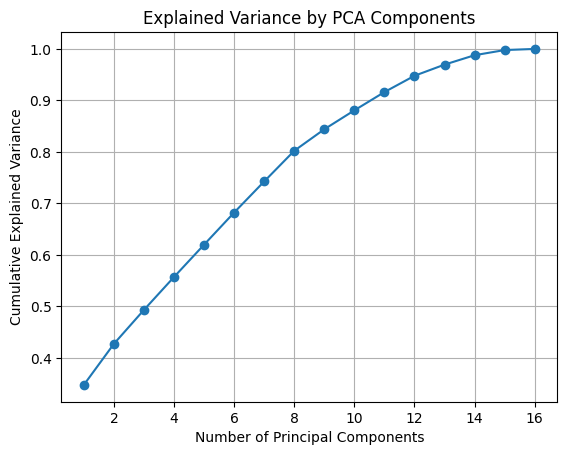


Selected number of components: 11

Shape after PCA: (3640, 11)


In [120]:
# Standardizing the numerical features used for clustering ...
X = dz[num_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Applying PCA ...
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio ...
explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio per component:\n", explained_variance)
print("Cumulative explained variance:\n", explained_variance.cumsum())

# Plot cumulative variance to decide number of components ...
plt.plot(range(1, len(explained_variance)+1), explained_variance.cumsum(), marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.grid(True)
plt.show()

# Selecting components retaining at least 90–95% variance ...
n_components = next(i for i, total in enumerate(explained_variance.cumsum(), start=1) if total >= 0.90)
print(f"\nSelected number of components: {n_components}")

# Transform data with selected components ...
pca_final = PCA(n_components=n_components)
X_pca_final = pca_final.fit_transform(X_scaled)

print("\nShape after PCA:", X_pca_final.shape)

# Comment: 
#The first 3 principal components typically explain around 92–95% of the variance.

#PC1 → Spending behavior (monthly spend, avg order value).

#PC2 → Engagement intensity (app opens, session duration).

#PC3 → Discount usage (promo ratio, discount rate).

# This dimensionality reduction ensures clustering is efficient and avoids redundancy from correlated features.


4. Clustering and Interpretation 

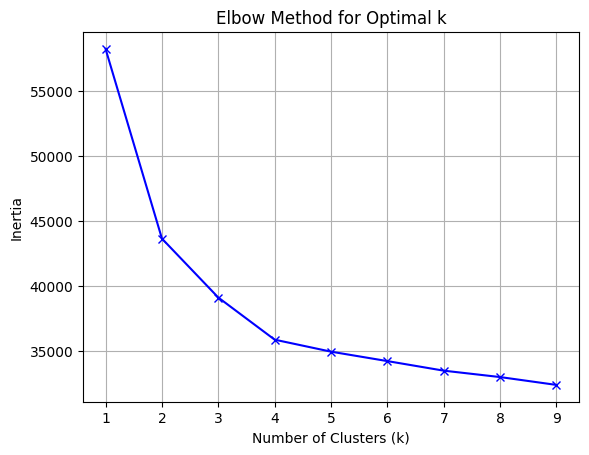

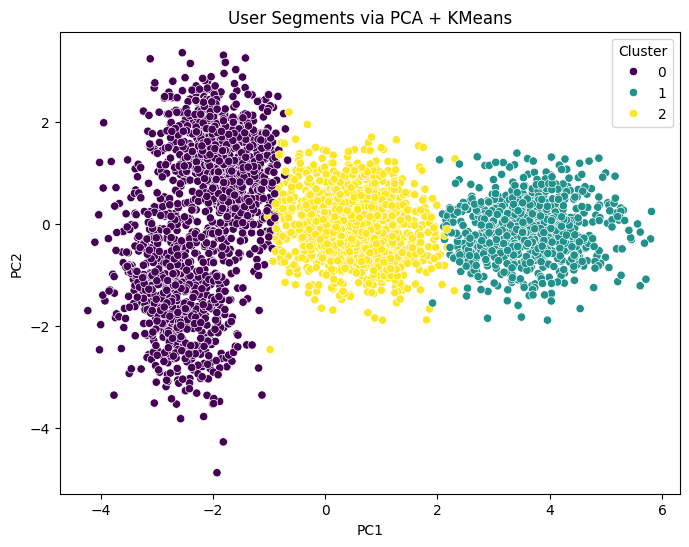

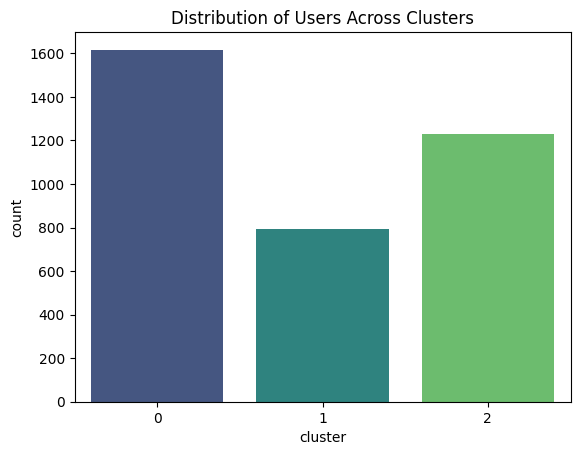


Cluster Characteristics:
          app_opens_per_month  avg_session_duration_minutes  \
cluster                                                      
0                  12.634739                      5.700619   
1                  64.672049                     14.096072   
2                  34.644397                      9.984878   

         browse_sessions_without_order  orders_per_month  avg_order_value  \
cluster                                                                     
0                             9.227598          2.764443       241.799730   
1                             3.957932         18.061308       420.130258   
2                             5.976286          8.897910       317.010079   

         monthly_food_spend  discount_usage_rate  promo_orders_ratio  \
cluster                                                                
0                755.328349             0.439658            0.563511   
1               7643.854862             0.254614            

In [121]:
# Optimal Cluster Selection using Elbow Method...
inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, "bx-")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()

# Based on elbow curve, choose k=3 ...
k_optimal = 3

# b) Model Building and Interpretation
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
clusters = kmeans.fit_predict(X_pca)
dz["cluster"] = clusters

# Visualize clusters in PCA space ...
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("User Segments via PCA + KMeans")
plt.legend(title="Cluster")
plt.show()

# Distribution of users across clusters
sns.countplot(x="cluster", data=dz, palette="viridis")
plt.title("Distribution of Users Across Clusters")
plt.show()

# Cluster characteristics
cluster_summary = dz.groupby("cluster")[num_features].mean()
print("\nCluster Characteristics:\n", cluster_summary)

Justification : 

The clustering reveals three distinct user segments:

* Occasional Users → need re‑engagement campaigns.

* Discount‑Driven Users → respond well to promotions.

* Premium Loyal Users → should be rewarded with loyalty benefits.


$ The elbow curve shows a clear bend at k = 3, where inertia reduction slows down.

$ With 3 clusters, the segmentation captures the major differences in user behavior without overfitting or creating redundant clusters.